# Bivariate Analysis with Churn (Statistical Testing)

Objective:
To identify statistically significant differences between churned and non-churned customers.

Approach:
- Compare feature distributions across churn groups
- Perform statistical hypothesis testing
- Validate findings with p-values

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, mannwhitneyu

In [2]:
df = pd.read_csv("../dataset/processed/credit_card_clean.csv")

df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

In [3]:
churn = df[df["Attrition_Flag"] == 1]
non_churn = df[df["Attrition_Flag"] == 0]

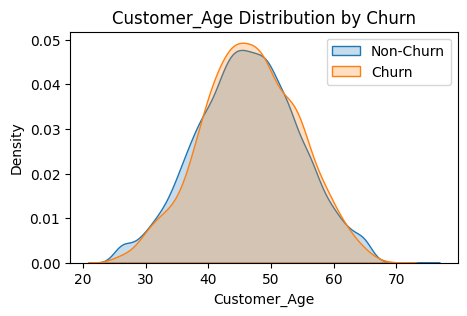

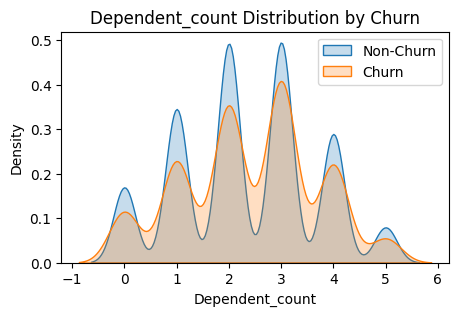

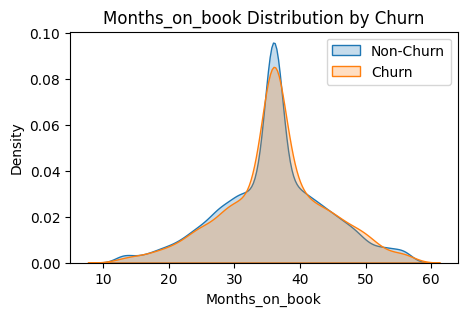

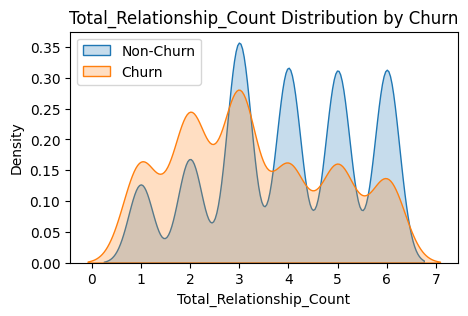

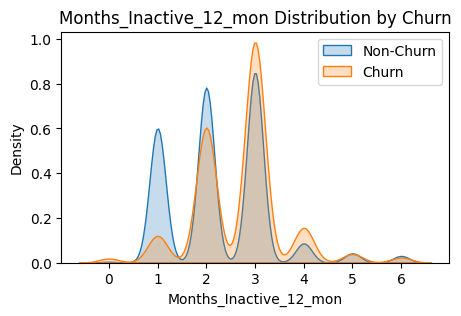

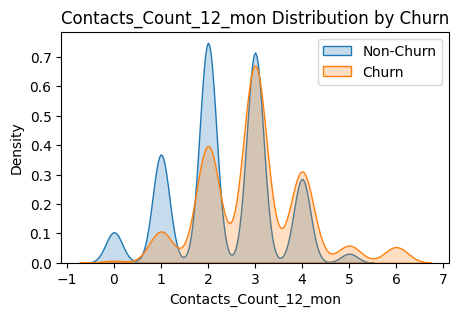

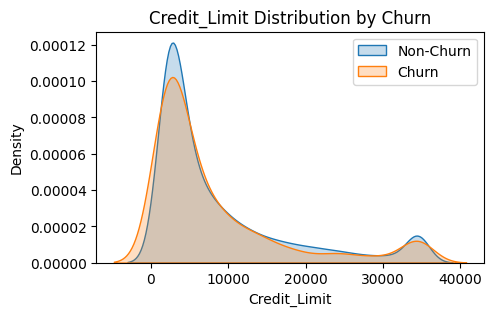

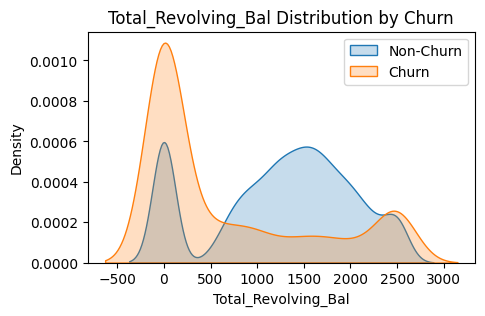

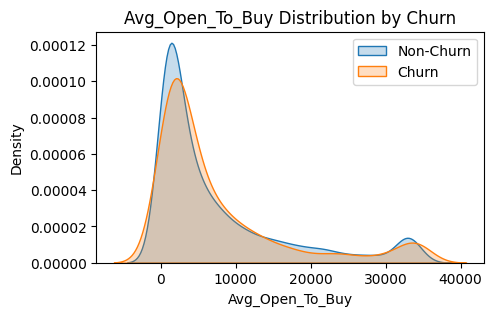

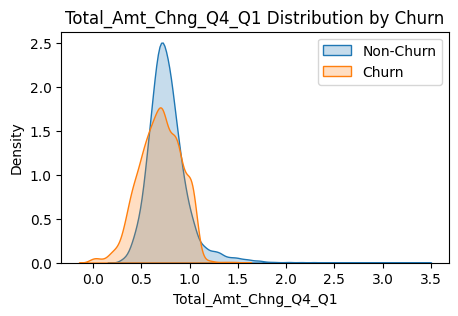

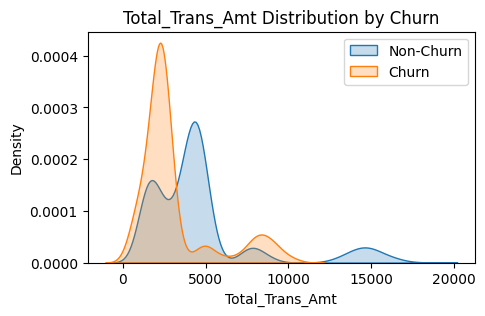

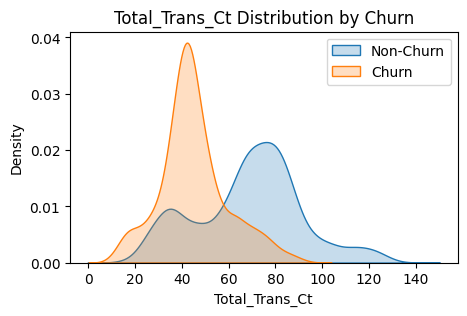

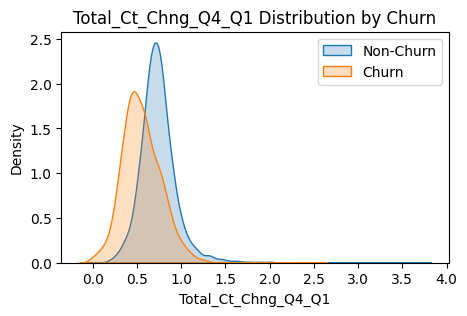

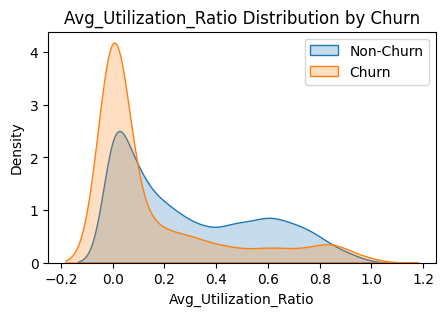

C:\Users\91914\AppData\Local\Temp\ipykernel_17732\2041506247.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(churn[col], label="Churn", fill=True)


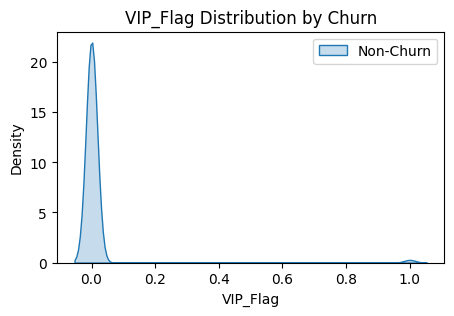

In [4]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    if col != "Attrition_Flag":
        plt.figure(figsize=(5,3))
        sns.kdeplot(non_churn[col], label="Non-Churn", fill=True)
        sns.kdeplot(churn[col], label="Churn", fill=True)
        plt.title(f"{col} Distribution by Churn")
        plt.legend()
        plt.show()

- H0 (Null): No difference between churn & non-churn
- H1 (Alt): Significant difference exists

In [5]:
results = []

for col in num_cols:
    if col != "Attrition_Flag":
        
        # t-test
        t_stat, t_p = ttest_ind(
            churn[col], 
            non_churn[col], 
            equal_var=False
        )
        
        # Mann-Whitney (non-parametric)
        u_stat, u_p = mannwhitneyu(
            churn[col], 
            non_churn[col]
        )
        
        results.append([col, t_p, u_p])

results_df = pd.DataFrame(
    results, 
    columns=["Feature", "T-test p-value", "Mann-Whitney p-value"]
)

results_df.sort_values(by="Mann-Whitney p-value")

,Feature,T-test p-value,Mann-Whitney p-value
11,Total_Trans_Ct,0.000000e+00,0.000000e+00
12,Total_Ct_Chng_Q4_Q1,7.156056e-173,1.908241e-216
7,Total_Revolving_Bal,7.089719e-113,1.915679e-129
13,Avg_Utilization_Ratio,2.782074e-72,2.869097e-129
10,Total_Trans_Amt,6.349082e-106,2.719009e-112
5,Contacts_Count_12_mon,6.687312e-89,1.110888e-80
4,Months_Inactive_12_mon,1.717553e-60,5.423116e-67
3,Total_Relationship_Count,3.225023e-48,2.905717e-51
9,Total_Amt_Chng_Q4_Q1,1.305897e-39,1.064474e-24
6,Credit_Limit,1.642963e-02,3.007841e-07


In [6]:
significant = results_df[
    results_df["Mann-Whitney p-value"] < 0.05
]

significant

,Feature,T-test p-value,Mann-Whitney p-value
1,Dependent_count,5.251960e-02,3.472886e-02
3,Total_Relationship_Count,3.225023e-48,2.905717e-51
4,Months_Inactive_12_mon,1.717553e-60,5.423116e-67
5,Contacts_Count_12_mon,6.687312e-89,1.110888e-80
6,Credit_Limit,1.642963e-02,3.007841e-07
7,Total_Revolving_Bal,7.089719e-113,1.915679e-129
8,Avg_Open_To_Buy,9.771547e-01,5.652366e-03
9,Total_Amt_Chng_Q4_Q1,1.305897e-39,1.064474e-24
10,Total_Trans_Amt,6.349082e-106,2.719009e-112
11,Total_Trans_Ct,0.000000e+00,0.000000e+00


# Statistical Findings

Features with p-value < 0.05 are statistically significant.

Key Observations:

- Transaction-related features show strong statistical separation
- Engagement and inactivity metrics are highly significant
- Credit-related features show moderate influence

Conclusion:
Churn is strongly driven by behavioral engagement rather than static demographics.

In [7]:
def cohen_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.std()**2 + y.std()**2)/2)

effect_sizes = []

for col in num_cols:
    if col != "Attrition_Flag":
        d = cohen_d(churn[col], non_churn[col])
        effect_sizes.append([col, d])

effect_df = pd.DataFrame(effect_sizes, columns=["Feature", "Effect Size"])

effect_df.sort_values(by="Effect Size", key=abs, ascending=False)

,Feature,Effect Size
11,Total_Trans_Ct,-1.236203
12,Total_Ct_Chng_Q4_Q1,-0.826749
7,Total_Revolving_Bal,-0.692059
5,Contacts_Count_12_mon,0.567211
10,Total_Trans_Amt,-0.524746
13,Avg_Utilization_Ratio,-0.498752
4,Months_Inactive_12_mon,0.437030
3,Total_Relationship_Count,-0.408696
9,Total_Amt_Chng_Q4_Q1,-0.361589
14,VIP_Flag,-0.155848


# Effect Size Interpretation

- |d| > 0.8 → Strong effect
- |d| > 0.5 → Moderate effect
- |d| > 0.2 → Weak effect

This helps quantify the magnitude of difference, not just significance.

# Key Research Insights

1. Transaction Velocity and Total Transactions show strong statistical significance, confirming behavioral disengagement as a primary churn driver.

2. Months Inactive has a high effect size, indicating inactivity is a leading indicator of churn.

3. Credit Limit alone is not a strong predictor — behavior matters more than capacity.

4. Engagement-based features outperform demographic features in explaining churn.

Final Conclusion:
Customer churn is driven by behavioral decay rather than static attributes.